In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import re

from analysis_scripts.us_analysis import *
from analysis_scripts.md_analysis import *
from analysis_scripts.gbsa_analysis import *
from analysis_scripts.docking_analysis import *

from analysis_scripts.plotstyle import set_rcparams
set_rcparams() # set plotting style

In [4]:
ROOT = Path("/home/btan/Documents/MolecularGluesBFE")


def classify_rmsd_state(dof):
    """
    Classify RMSD calculations using the repository naming convention.

    Bound:
        *_only
        *with*

    Bulk:
        *_bulk
        bare component names
    """
    dof_lower = dof.lower()

    # Check bulk first because names such as
    # BD1_only_bulk and BD2withBD1_bulk contain "_only" or "with".
    if "_bulk" in dof_lower:
        return "Bulk-state RMSD"

    if dof_lower.endswith("_only") or "with" in dof_lower:
        return "Bound-state RMSD"

    return "Bulk-state RMSD"


def load_equilibration_times():
    records = []

    # Separation equilibration files
    for path in sorted(
        ROOT.glob("*/US/separation/results/run*/RED/equil_times.csv")
    ):
        relative_parts = path.relative_to(ROOT).parts

        system = relative_parts[0]
        repeat = int(relative_parts[4].replace("run", ""))

        data = pd.read_csv(path)

        for equilibration_time in data["equilibration_time_ns"]:
            records.append({
                "system": system,
                "stage": "Separation",
                "dof": "separation",
                "repeat": repeat,
                "equilibration_time_ns": equilibration_time,
                "file": str(path),
            })

    # RMSD equilibration files
    for path in sorted(
        ROOT.glob("*/US/RMSD/results/*/run*/RED/equil_times.csv")
    ):
        relative_parts = path.relative_to(ROOT).parts

        system = relative_parts[0]
        dof = relative_parts[4]
        repeat = int(relative_parts[5].replace("run", ""))

        stage = classify_rmsd_state(dof)
        data = pd.read_csv(path)

        for equilibration_time in data["equilibration_time_ns"]:
            records.append({
                "system": system,
                "stage": stage,
                "dof": dof,
                "repeat": repeat,
                "equilibration_time_ns": equilibration_time,
                "file": str(path),
            })

    if not records:
        raise RuntimeError(
            f"No equil_times.csv files found below {ROOT}"
        )

    return pd.DataFrame(records)


equilibration_df = load_equilibration_times()

# Display summary statistics
summary = (
    equilibration_df
    .groupby("stage")["equilibration_time_ns"]
    .agg(
        n="count",
        mean_ns="mean",
        std_ns="std",
        median_ns="median",
        minimum_ns="min",
        maximum_ns="max",
    )
)

display(summary)

,n,mean_ns,std_ns,median_ns,minimum_ns,maximum_ns
stage,,,,,,
Bound-state RMSD,1983,4.841278,2.801813,4.94600,0.0,9.0005
Bulk-state RMSD,1878,4.428504,2.921198,4.31850,0.0,15.9475
Separation,1530,1.569528,2.378695,0.30525,0.0,9.0005


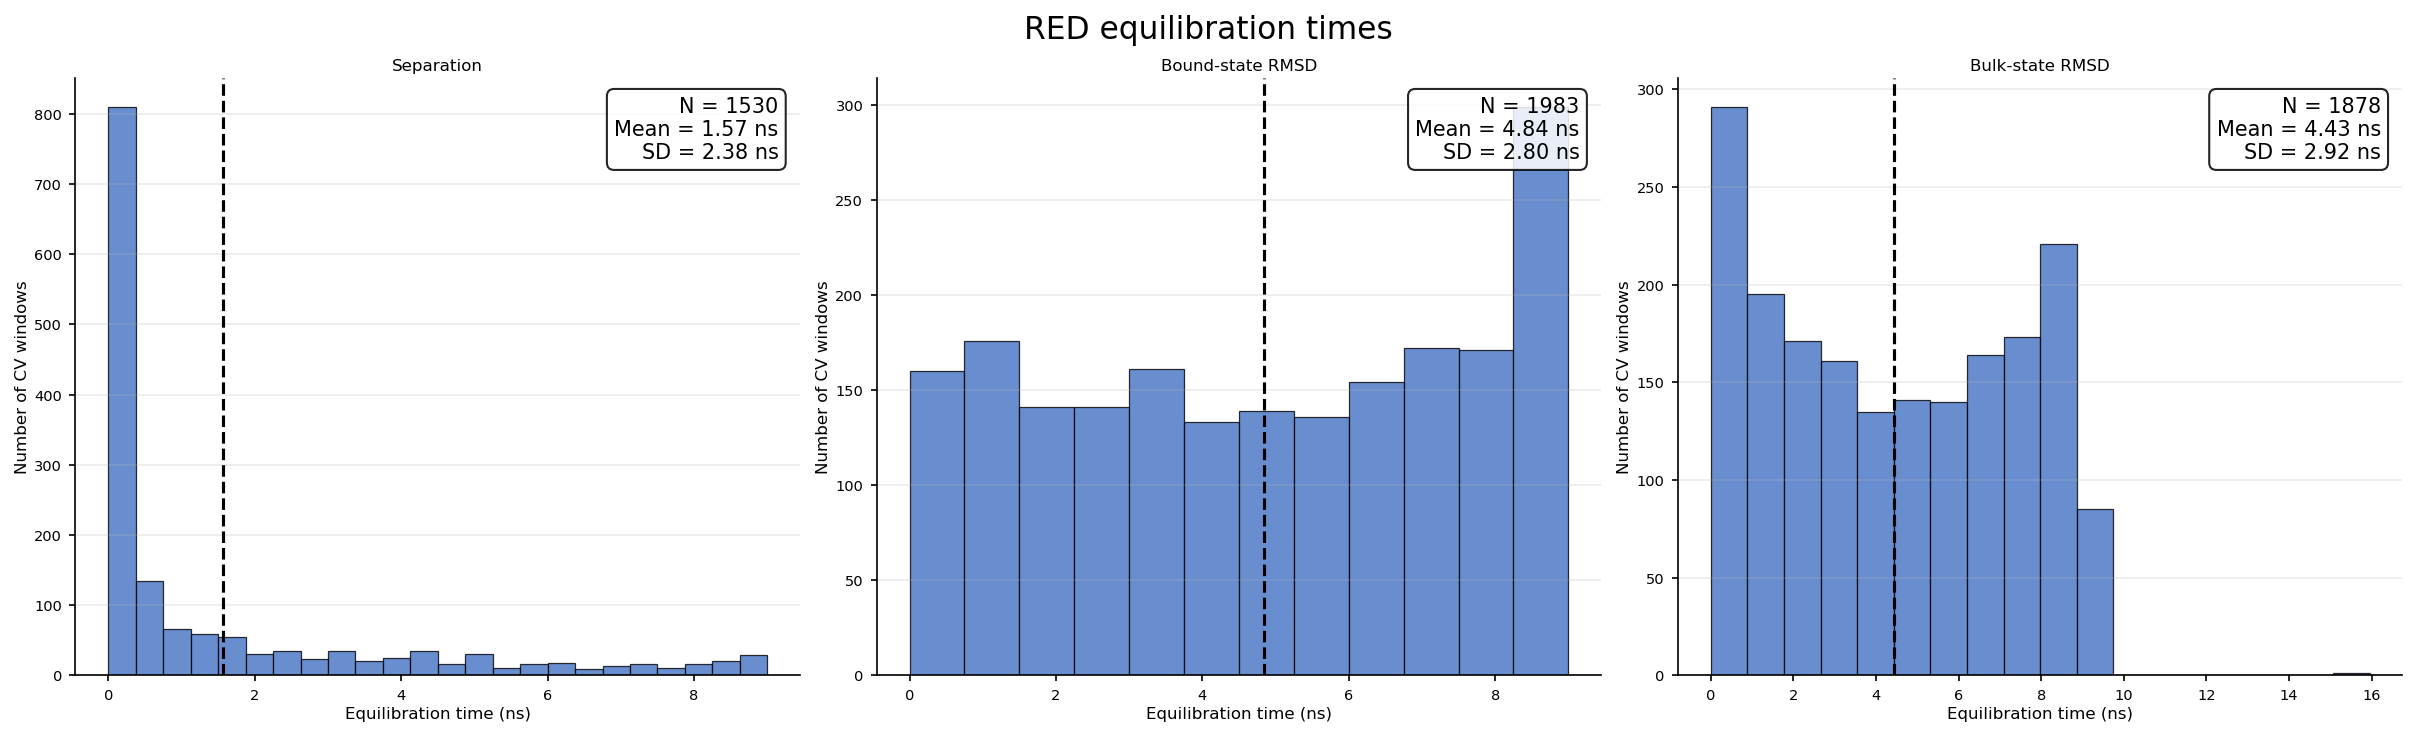

Saved figure to: /home/btan/Documents/MolecularGluesBFE/equilibration_time_histograms.png


In [5]:
stages = [
    "Separation",
    "Bound-state RMSD",
    "Bulk-state RMSD",
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 4.8),
    constrained_layout=True,
)

for ax, stage in zip(axes, stages):
    values = (
        equilibration_df.loc[
            equilibration_df["stage"] == stage,
            "equilibration_time_ns",
        ]
        .dropna()
        .to_numpy()
    )

    if len(values) == 0:
        ax.set_title(f"{stage}\nNo data")
        ax.set_axis_off()
        continue

    mean = np.mean(values)
    std = np.std(values, ddof=1)

    ax.hist(
        values,
        bins="auto",
        color="#4472C4",
        alpha=0.8,
        edgecolor="black",
        linewidth=0.6,
    )

    ax.axvline(
        mean,
        color="black",
        linestyle="--",
        linewidth=1.5,
    )

    statistics_text = (
        f"N = {len(values)}\n"
        f"Mean = {mean:.2f} ns\n"
        f"SD = {std:.2f} ns"
    )

    ax.text(
        0.97,
        0.97,
        statistics_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": "black",
            "alpha": 0.85,
        },
    )

    ax.set_title(stage)
    ax.set_xlabel("Equilibration time (ns)")
    ax.set_ylabel("Number of CV windows")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("RED equilibration times", fontsize=15)

output_path = ROOT / "equilibration_time_histograms.png"
# fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {output_path}")

### Plotting equilibration time for a single US repeat

<Axes: xlabel='Angstrom', ylabel='Equilibration time (ns)'>

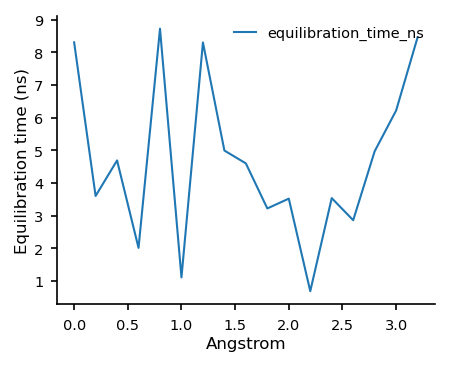

In [15]:
eq_df = write_equilibration_times('CRBN_len_CK1a', 'RMSD', dof='CRBN_len_only', run_number=3)
eq_df.plot(x='CV', y='equilibration_time_ns', ylabel='Equilibration time (ns)', xlabel='Angstrom')